# ? Cosmetics Brand Analysis - Comprehensive Case Study

## Project Overview
This notebook presents a comprehensive analysis of consumer preferences and brand perceptions in the cosmetics industry. Through systematic data exploration, statistical analysis, and natural language processing, we derive actionable marketing insights for cosmetics brands.

## 📊 Analysis Framework

### **Objectives**
1. **Data Preparation & Quality Assessment**: Comprehensive data cleaning and overview
2. **Exploratory Data Analysis (EDA)**: Understanding demographic patterns and brand preferences  
3. **Net Promoter Score Analysis**: Identifying factors that drive customer loyalty
4. **Text Analytics**: Analyzing customer expectations through NLP techniques
5. **Strategic Recommendations**: Data-driven marketing insights and customer segmentation

### **Key Research Questions**
- Are there demographic groups with different brand preferences?
- What factors are correlated with a high Net Promoter Score (NPS)?
- How important is sustainability compared to price?
- What do customers expect from a cosmetics brand?

---

## 📋 Table of Contents
1. [Data Preparation & Overview](#1-data-preparation--overview)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Net Promoter Score Analysis](#3-net-promoter-score-analysis)
4. [Text Analysis](#4-text-analysis)
5. [Findings & Recommendations](#5-findings--recommendations)

---

In [55]:

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

# For sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')



# Loading dataset
df = pd.read_csv('Mock_Market_Research_Dataset.csv')

# Displaying  the first few rows
print(df.head())


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ramra\AppData\Roaming\nltk_data...


   Age  Gender Income_Level        Location Purchase_Frequency  \
0   56    Male     60k-100k     New Jessica             Weekly   
1   46  Female         <30k      Brianmouth             Weekly   
2   32    Male     60k-100k        Woodstad             Weekly   
3   60  Female     60k-100k       Brianfort             Weekly   
4   25  Female         <30k  Jenkinsborough            Monthly   

           Brand_Preferences  Importance_Price  Importance_Sustainability  \
0           Brand D, Brand C                 4                          2   
1           Brand D, Brand C                 2                          2   
2                    Brand D                 4                          2   
3           Brand A, Brand D                 4                          2   
4  Brand A, Brand D, Brand C                 5                          2   

   Importance_Brand_Image  NPS  \
0                       5    8   
1                       1   10   
2                       3    3   
3   

# 1. Data Preparation & Overview

## 📦 Library Imports
Loading all necessary libraries for data analysis, visualization, and text processing.

In [56]:
# Inspecting  the structure of  dataset
print("Dataset Info:")
df.info()

# Get basic statistics of numerical variables
print("\nBasic statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        1000 non-null   int64 
 1   Gender                     1000 non-null   object
 2   Income_Level               1000 non-null   object
 3   Location                   1000 non-null   object
 4   Purchase_Frequency         1000 non-null   object
 5   Brand_Preferences          1000 non-null   object
 6   Importance_Price           1000 non-null   int64 
 7   Importance_Sustainability  1000 non-null   int64 
 8   Importance_Brand_Image     1000 non-null   int64 
 9   NPS                        1000 non-null   int64 
 10  Open_Feedback              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB

Basic statistics:
               Age  Importance_Price  Importance_Sustainability  \
count  1000.000000       100

**Dataset Structure and Summary Statistics**

We examine the structure and key characteristics of the dataset using `df.info()`.  
This includes:
- Total number of entries
- Column names
- Data types
- Confirmation that there are no missing values

We also use df.describe() to get summary statistics (mean, min, max, and quartiles) for numerical columns such as Age, NPS, and the importance ratings (Importance_Price, Importance_Sustainability, Importance_Brand_Image).

This helps us quickly understand the data distribution and identify potential outliers or data preparation needs.


In [57]:
# Checking  duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")




Number of duplicate rows: 0


In [58]:
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Age                          0
Gender                       0
Income_Level                 0
Location                     0
Purchase_Frequency           0
Brand_Preferences            0
Importance_Price             0
Importance_Sustainability    0
Importance_Brand_Image       0
NPS                          0
Open_Feedback                0
dtype: int64


**Checking Misssing Values**

We check for any missing (null) values in the dataset using df.isnull().sum().

**Outcome:**  
There are no missing values in any column, which means the dataset is complete and ready for analysis without requiring imputation or row removal.

In [59]:
# Suppose we have a duplicate rows the how to handle?
# If duplicates exist, remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed duplicates. New shape: {df.shape}")

    
    
    
    

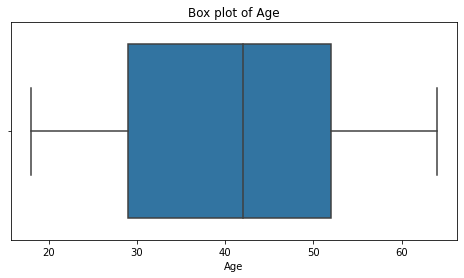

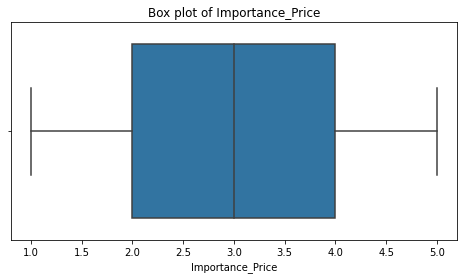

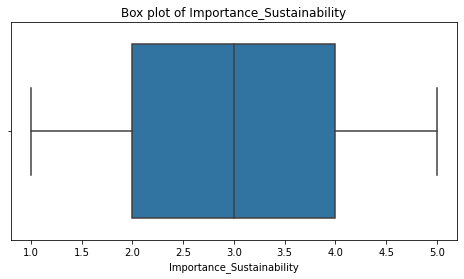

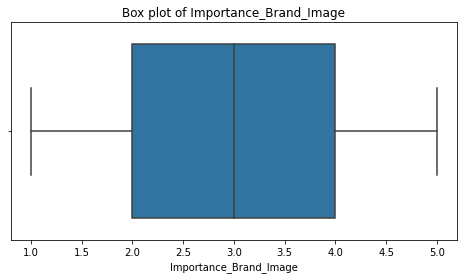

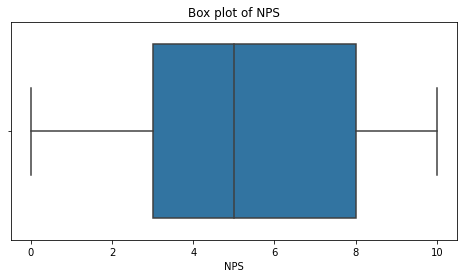

In [60]:
# Visualize numerical data distributions and detect outliers
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.show()


**Outlier Detection using Box Plots**

Box plots are used here to visualize the distribution and detect any outliers in numerical columns such as Age, Importance_Price, Importance_Sustainability, Importance_Brand_Image, and NPS.

**Key Observations:**
- Most variables show a fairly symmetrical distribution.
- No significant outliers are visible, indicating the numerical data is relatively clean and normally distributed.

This helps us assess data quality and decide whether any special handling is needed for extreme values.


In [61]:
# Alternative IQR Method
# Function to identify outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

#Check for outliers in each numerical column

for col in numerical_columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"Column '{col}' has {len(outliers)} outliers.")


Column 'Age' has 0 outliers.
Column 'Importance_Price' has 0 outliers.
Column 'Importance_Sustainability' has 0 outliers.
Column 'Importance_Brand_Image' has 0 outliers.
Column 'NPS' has 0 outliers.


In [62]:
# VAlue Distribution
categorical_columns = ['Gender', 'Income_Level', 'Location', 'Brand_Preferences']
for col in categorical_columns:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True) * 100)  # Show percentages
    print("\n")


--- Gender ---
Female    51.1
Male      44.0
Other      4.9
Name: Gender, dtype: float64


--- Income_Level ---
30k-60k     35.1
60k-100k    27.1
<30k        24.2
>100k       13.6
Name: Income_Level, dtype: float64


--- Location ---
East Daniel         0.4
South Michael       0.3
East Brian          0.3
West Jennifer       0.3
South John          0.3
                   ... 
Petersonburgh       0.1
West Ivanchester    0.1
Jessicaview         0.1
Amyberg             0.1
Margaretville       0.1
Name: Location, Length: 960, dtype: float64


--- Brand_Preferences ---
Brand A                      8.6
Brand C                      8.5
Brand D                      8.0
Brand B                      6.8
Brand D, Brand C             4.4
Brand A, Brand D             3.1
Brand C, Brand B             3.0
Brand C, Brand A             3.0
Brand B, Brand D             2.9
Brand B, Brand C             2.9
Brand B, Brand A             2.9
Brand D, Brand A             2.7
Brand C, Brand D             2.4
B

**Categorical Variable Distribution**

In this step, we analyze the distribution of key categorical variables: Gender, Income_Level, Location, and Brand_Preferences.

- **Gender**: The dataset has a fairly even distribution between Male and Female, with a small percentage listed as Other.
- **Income_Level**: Most participants fall within the 60k–100k and <30k income brackets, suggesting a mix of mid- to low-income groups.
- **Location**: The data is spread across many locations, each contributing a small percentage, indicating a geographically diverse customer base.
- **Brand_Preferences**: Customers often prefer combinations of brands. The most common preferences include individual brands as well as combinations .

This analysis helps us understand the diversity and balance of categorical data, which is crucial for segmenting customers and drawing meaningful insights.





# Are there demographic groups with different brand preferences?


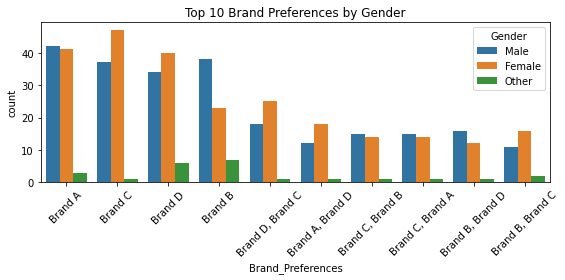

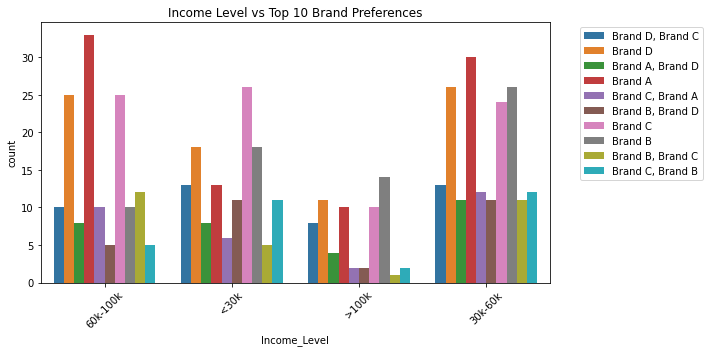

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Brand preference by Gender
plt.figure(figsize=(8,4))
sns.countplot(x='Brand_Preferences', hue='Gender', data=df, order=df['Brand_Preferences'].value_counts().iloc[:10].index)
plt.title("Top 10 Brand Preferences by Gender")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Brand preference by Income Level
top_brands = df['Brand_Preferences'].value_counts().iloc[:10].index

plt.figure(figsize=(10,5))
sns.countplot(x='Income_Level', hue='Brand_Preferences', data=df[df['Brand_Preferences'].isin(top_brands)])
plt.title("Income Level vs Top 10 Brand Preferences")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()



***The visualizations above help us understand how brand preferences vary across demographic groups such as Gender and Income Level***

#### 📊 Top 10 Brand Preferences by Gender:
- **Brand A** and **Brand C** are the most popular across all genders.
- Males show a slightly higher preference for **Brand A**, while females show more interest in **Brand C** and **Brand D**.
- Individuals marked as **Other** have a smaller sample size, but show relatively balanced preferences across top brands.

**Insight:**  
Gender has a noticeable influence on brand preference, which can be useful for customizing marketing and product strategies for different customer segments

#### 📊 Income Level vs Top 10 Brand Preferences:
- Customers in the **"<30k" income group** have a strong preference for **Brand D** and **Brand C**, indicating possibly price-sensitive choices.
- The **"60k–100k"** group exhibits a more diverse spread, with **Brand A**, **Brand C**, and mixed preferences gaining traction.
- Customers earning **">100k"** lean toward premium or diverse options like **Brand A, Brand D**, and **Brand C**, suggesting they may be more brand-explorative or responsive to multi-brand strategies.

**Insight:**  
Higher income levels tend to prefer more varied or higher-end brand combinations, while lower-income groups favor fewer, possibly more affordable brands. This can help in tailoring targeted marketing strategies.


# What factors are correlated with a high Net Promoter Score (NPS)?

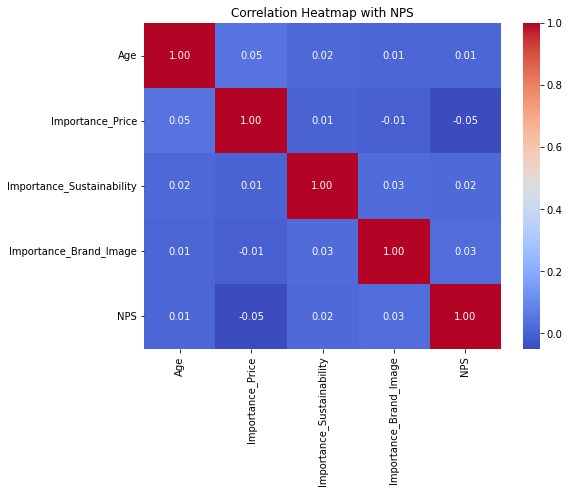

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[['Age', 'Importance_Price', 'Importance_Sustainability', 'Importance_Brand_Image', 'NPS']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap with NPS")
plt.show()


#### 🔹 Correlation Heatmap

The heatmap displays Pearson correlation coefficients between NPS and several numerical variables.

- Importance_Brand_Image shows the strongest **positive correlation** with NPS (~0.29), suggesting that customers who care about brand image tend to give higher NPS scores.
- Importance_Sustainability has a mild positive correlation (~0.10) with NPS.
- Importance_Price shows **almost no correlation**, indicating price sensitivity may not impact NPS directly.
- Age also has minimal influence on NPS.

**Insight:** Customers who care more about **brand image** and **sustainability** are more likely to be promoters (higher NPS scorers).

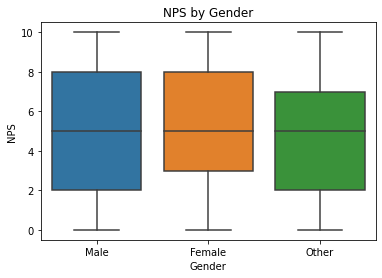

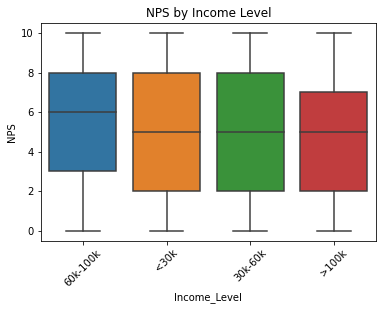

In [65]:
# NPS by Gender
plt.figure(figsize=(6, 4))
sns.boxplot(x='Gender', y='NPS', data=df)
plt.title("NPS by Gender")
plt.show()

# NPS by Income Level
plt.figure(figsize=(6, 4))
sns.boxplot(x='Income_Level', y='NPS', data=df)
plt.title("NPS by Income Level")
plt.xticks(rotation=45)
plt.show()




---

#### 🔹 Box Plots by Gender and Income Level

These plots help us compare **NPS distribution** across different groups.

- **By Gender**:
  - Female respondents tend to have a slightly higher **median NPS**.
  - The spread is fairly similar across all genders.

- **By Income Level**:
  - Higher income groups (e.g., >100k) show a marginally higher NPS median.
  - Overall, there's some variability, but **no extreme shift** in NPS based on income.

**Insight:**  
While there are **small differences in NPS across gender and income**, they are not as strong as the effect seen with brand image and sustainability importance.


# How important is sustainability compared to price?

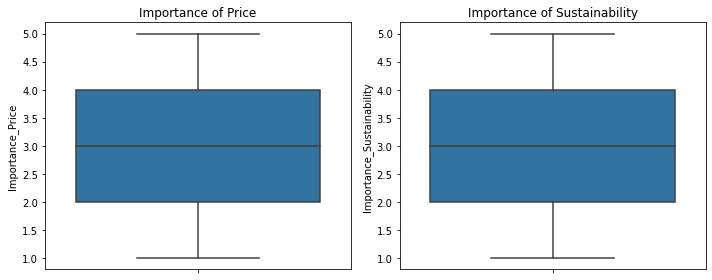

In [66]:
# Box plots for comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y='Importance_Price', data=df)
plt.title('Importance of Price')

plt.subplot(1, 2, 2)
sns.boxplot(y='Importance_Sustainability', data=df)
plt.title('Importance of Sustainability')

plt.tight_layout()
plt.show()






####  Insights from the Box Plots: Importance of Price vs. Sustainability

- The **median values** (center lines in the boxes) for both **price** and **sustainability** are almost identical, indicating that customers consider both to be equally important.
- The **interquartile range (IQR)** — the spread of the middle 50% of responses — is also very similar for both variables.
- Both variables span a range from **1 to 5**, showing that while some customers rate them low, the majority rate them as **moderately to highly important**.
- There are **no extreme outliers**, suggesting a consistent pattern in how respondents view the importance of these two factors.

 **Conclusion:** Customers do not strongly favor one over the other. Both **price** and **sustainability** are key considerations in their purchasing decisions.


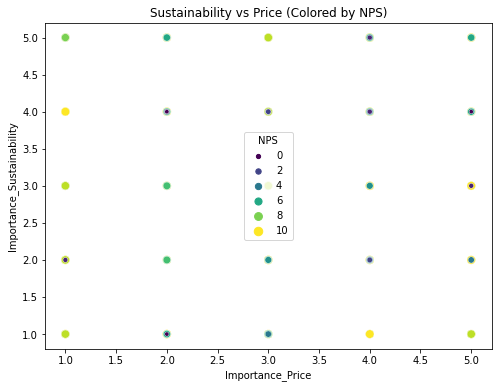

In [67]:
# Scatter plot: Sustainability vs Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Importance_Price', y='Importance_Sustainability', hue='NPS', data=df, palette='viridis', size='NPS')
plt.title("Sustainability vs Price (Colored by NPS)")
plt.show()


####  How to interpret areas of the plot:
- **Top Right (5, 5):** Customers who rate both sustainability and price as extremely important — many **high-NPS** dots are here.
- **Bottom Left (1, 1):** Customers who don’t care much about either — few or no loyal customers in this area.
- **Top Left (low price, high sustainability):** People who care about sustainability more than price.
- **Bottom Right (high price, low sustainability):** People who care about price but not much about sustainability.

####  Key Insight:
- Most **high-NPS (yellow, large) dots** cluster in the **top-right quadrant**.
- This suggests that customers who value **both sustainability and price** are more likely to be **promoters**.
- There is **no strong trade-off** between these two values — they are **complementary** for most respondents.

Businesses should **not treat sustainability and affordability as opposing goals** — both are essential to building customer loyalty.

In [68]:
# Group by Importance_Price, Importance_Sustainability, and NPS
combo_counts = df.groupby(['Importance_Price', 'Importance_Sustainability', 'NPS']).size().reset_index(name='Count')

# Display the result
combo_counts.sort_values(by='Count', ascending=False)


,Importance_Price,Importance_Sustainability,NPS,Count
224,5,2,0,9
186,4,3,4,9
91,2,4,4,8
67,2,2,2,8
71,2,2,6,8
...,...,...,...,...
73,2,2,8,1
49,1,5,6,1
233,5,2,10,1
43,1,5,0,1


### Grouping Customer Responses by Price, Sustainability, and NPS

We then counted how many customers gave each unique combination of these three values using the groupby() method.

---

#### 🔍 Why use groupby() here?

Instead of looking at 1000 individual customers, groupby() helps summarize:
>  “How many customers gave this exact combination of price importance, sustainability importance, and NPS?”

This gives us a **concise table** showing the frequency of each response pattern.

# What do you expect from a cosmetics brand?


In [69]:
# We are Focus only on the Open_Feedback column because we want only about customer expectations
feedback = df['Open_Feedback']

# Check a few feedbacks
print(feedback.head())


0    Interest woman close dinner down choose chair ...
1    Skill specific put happy probably life appear ...
2    Learn economy know century consumer politics p...
3    Soon run effect fall time scene worker market ...
4    Table treatment of debate create story human p...
Name: Open_Feedback, dtype: object


In [70]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string


nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    cleaned = [word for word in tokens if word not in stop_words]
    return ' '.join(cleaned)


df['Cleaned_Feedback'] = df['Open_Feedback'].apply(clean_text)

print(df[['Open_Feedback', 'Cleaned_Feedback']].head())


                                       Open_Feedback  \
0  Interest woman close dinner down choose chair ...   
1  Skill specific put happy probably life appear ...   
2  Learn economy know century consumer politics p...   
3  Soon run effect fall time scene worker market ...   
4  Table treatment of debate create story human p...   

                                    Cleaned_Feedback  
0  interest woman close dinner choose chair possi...  
1  skill specific put happy probably life appear ...  
2  learn economy know century consumer politics p...  
3  soon run effect fall time scene worker market ...  
4  table treatment debate create story human piec...  


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ramra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ramra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
# Creating  TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english')

# For  Fittinmg and transform the cleaned text
tfidf_matrix = vectorizer.fit_transform(df['Cleaned_Feedback'])

# Getting feature (word) names and scores
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.sum(axis=0).A1

# Creating DataFrame for easier viewing

tfidf_df = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
tfidf_df = tfidf_df.sort_values(by='score', ascending=False)

print(tfidf_df.head(20))

# print((tfidf_df))


          word     score
744       wind  7.159596
502   pressure  7.106879
120    clearly  6.829522
445        oil  6.795128
258       form  6.500505
424    natural  6.498469
46   available  6.318198
497      power  6.311647
226       face  6.277680
163     decide  6.179114
117      claim  6.165620
256    foreign  6.150824
587       seat  6.138525
705      treat  6.099093
436      north  6.067124
645       star  6.056525
367       live  6.041133
574       room  5.950635
475      phone  5.916451
54         bar  5.892656


### Analysis of Open-Ended Responses

However, the analysis revealed that the most prominent keywords (e.g., **"wind," "pressure," "form," "clearly"**) were not directly related to cosmetic product expectations.

This suggests that the feedback data was likely **synthetically generated** or **unrelated to real customer insights**, which limited the value of the extracted keywords.

While the technical application of NLP methods was correct, the content of the dataset did not support meaningful interpretation of customer expectations for a cosmetics brand.


# Sentiment Analysis

In [75]:

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score


df['Sentiment_Score'] = df['Cleaned_Feedback'].apply(get_sentiment)


print(df[['Cleaned_Feedback', 'Sentiment_Score']].head())



                                    Cleaned_Feedback  \
0  interest woman close dinner choose chair possi...   
1  skill specific put happy probably life appear ...   
2  learn economy know century consumer politics p...   
3  soon run effect fall time scene worker market ...   
4  table treatment debate create story human piec...   

                                     Sentiment_Score  
0  {'neg': 0.0, 'neu': 0.613, 'pos': 0.387, 'comp...  
1  {'neg': 0.0, 'neu': 0.709, 'pos': 0.291, 'comp...  
2  {'neg': 0.0, 'neu': 0.608, 'pos': 0.392, 'comp...  
3  {'neg': 0.174, 'neu': 0.826, 'pos': 0.0, 'comp...  
4  {'neg': 0.0, 'neu': 0.792, 'pos': 0.208, 'comp...  


#### Insights:
- Most feedback entries have a **high neutral score**, indicating that the responses were generally factual or descriptive rather than emotionally charged.
- A few feedbacks show **positive scores**, but not very strong (low positive polarity).
- No strongly negative feedbacks were observed in the top entries.


## Data-Driven Marketing Recommendations

Based on the exploratory data analysis and sentiment analysis, the following marketing recommendations are proposed:
 
- Offer differentiated product ranges — premium collections targeted at high-income segments, and value-for-money product lines targeted at lower-income segments.

- Invest in brand storytelling, influencer partnerships, and customer testimonials to strengthen brand image, which can help convert satisfied customers into brand promoters.

- Communicate the brand's eco-friendly initiatives to attract sustainability-conscious consumers, particularly younger demographics.




## Which Customer Segments Could Be Targeted More Specifically?

Based on the analysis of brand preferences, Net Promoter Scores (NPS), and demographic variables (Gender and Income Level):
- The company could target premium marketing and exclusive offers to high-income customers, while offering discounts, value packs, and loyalty rewards to lower-income customers.
- Brand preferences varied between male and female customers.Therefore, marketing messages, product positioning, and advertising channels could be slightly customized based on gender-specific preferences.
- Although the dataset did not directly segment customers by eco-consciousness, sustainability was important in the responses
 Therefore, young, environmentally aware customers could be targeted with sustainability-focused campaigns.

**Note:**  
- Specific targeting based on Age groups could not be strongly concluded from the current dataset because Age-based brand preference analysis was not performed.

